Import Libraries

In [1]:
import jax
import flax
import optax
from jax import lax, random, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from flax import linen as nn

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

# choose GPU
import os
#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)

In [2]:
n_gpu = len(jax.devices())
jax.devices()

[cuda(id=0), cuda(id=1)]

13. 2D Poisson Equation

        (u_xx + u_yy) = s

In [ ]:
# dat = np.loadtxt('/content/drive/MyDrive/Colab Notebooks/data/data_T20_S30_G50_reduced.dat', skiprows=1, delimiter=',')
dat = np.loadtxt('../data/data_T20_S30_G50_reduced.dat', skiprows=1, delimiter=',')
print (dat.shape)
# crop
dat = dat[(dat[:,1] > 150) & (dat[:,1] < 350)]
print (dat.shape)
print (np.unique(dat[:,0]).shape, np.unique(dat[:,1]).shape)

x_l, x_u, y_l, y_u = np.unique(dat[:,0]).min(), np.unique(dat[:,0]).max(), np.unique(dat[:,1]).min(), np.unique(dat[:,1]).max()
ext = [x_l, x_u, y_l, y_u]     # plot boundaryo
print (ext)

(122880, 4)
(48000, 4)
(240,) (200,)
[0.5, 239.5, 150.5, 349.5]


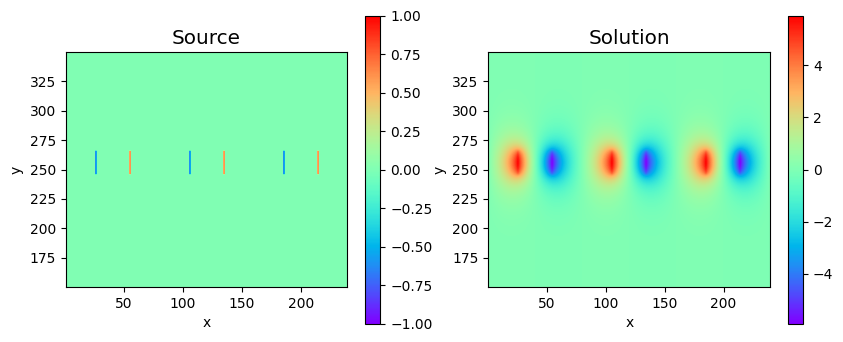

In [4]:
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(1,2,1)
s_plot = dat[:,2].reshape(240, -1).T
mesh2 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.); 
plt.colorbar(mesh2); plt.xlabel('x'); plt.ylabel('y'); 
plt.title('Source', fontsize='x-large'); 
ax1 = fig.add_subplot(1,2,2)
s_plot = dat[:,3].reshape(240, -1).T
mesh2 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.); 
plt.colorbar(mesh2); plt.xlabel('x'); plt.ylabel('y'); 
plt.title('Solution', fontsize='x-large'); 

In [5]:
# training data - split into spatial input (x, y), source term s, and ground truth (u_sim)
dat = jnp.array(dat)
x, y, s, u_sim = dat[:,0].reshape(-1, 1), dat[:,1].reshape(-1, 1), dat[:,2].reshape(-1, 1), dat[:,3].reshape(-1, 1)

# BCs
bc_pl, bc_pu = ((x == x_l)).flatten(), ((x == x_u)).flatten()
bc_n = ((y == y_l) | (y == y_u)).flatten()
#bc_d = ((y == y_l) | (y == y_u) | (x == x_l) | (x == x_u)).flatten()
#print ('Dirichlet BC: #sample = %d'%bc_d.sum())
print ('Neumann BC: #sample = %d'%bc_n.sum())
print ('Periodic BC: #sample = %d %d'%(bc_pl.sum(), bc_pu.sum()))

Neumann BC: #sample = 480
Periodic BC: #sample = 200 200


FrPINN

In [ ]:
# construct randomization B-PINN for linear/nonlinear ODE/PDEs
@jit
def get_f(x, y, weights):
    h1 = (x - 125.) / 100. * weights[0] + (y - 250.) / 100. * weights[1] + weights[2]
    h2 = (x - 125.) / 100. * weights[3] + (y - 250.) / 100. * weights[4] + weights[5]
    h3 = (x - 125.) / 100. * weights[6] + (y - 250.) / 100. * weights[7] + weights[8]
    h4 = (x - 125.) / 100. * weights[9] + (y - 250.) / 100. * weights[10] + weights[11]
    h5 = (x - 125.) / 100. * weights[12] + (y - 250.) / 100. * weights[13] + weights[14]
    h6 = (x - 125.) / 100. * weights[15] + (y - 250.) / 100. * weights[16] + weights[17]
    f = jnp.hstack([jnp.sin(h1), jnp.sin(1*jnp.pi*h1), jnp.sin(2*jnp.pi*h1), nn.softplus(h2), jnp.tanh(h3),
                    jnp.sin(h4), jnp.sin(1*jnp.pi*h4), jnp.sin(2*jnp.pi*h4), nn.softplus(h5), jnp.tanh(h6)])
    return f

# obtain f_dir
def get_f_dir(get_f, x, y, weights):
    f_x, f_y = jacfwd(get_f)(x, y, weights), jacfwd(get_f, argnums=1)(x, y, weights)
    f_xx, f_yy = jacfwd(jacfwd(get_f))(x, y, weights), jacfwd(jacfwd(get_f, argnums=1), argnums=1)(x, y, weights)
    return f_x, f_y, f_xx, f_yy

### (Explore to change the above AD computation in get_f_dir to numerical differentiation, e.g., 2nd order central difference) 

f_vmap = vmap(get_f, in_axes=(0, 0, None))
f_dir_vmap = vmap(get_f_dir, in_axes=(None, 0, 0, None))

In [7]:
# no. neurons
n_node = 150

# generate weight & bias dist.
seed = 0
key, rng = random.split(random.PRNGKey(seed))
key, rng = random.split(rng) # update random generator
weights_n = random.truncated_normal(key, shape=(n_node, 9), lower=-1, upper=1)
key, rng = random.split(rng) # update random generator
weights_u = random.uniform(key, (n_node, 9), minval=-1, maxval=1)

# regularization
lamb = 1e-4

In [8]:
# pre-train hyper-parameters for nonlinear hidden layer weights
param = jnp.array([ 10.09822957,  -3.87555686, -16.929685  ,  -2.77833317,
                   -15.22937101, -17.93026106,   0.75740902,  -1.08731573,
                   -15.22055726,   0.20566555,   2.09818805,   1.31966254,
                    41.06236758, -24.7403773 , -67.06658613,   1.87400817,
                     0.53709715,  12.50666705, -12.6852006 , -13.75918575,
                    23.12318144, -13.35527196,   7.92822574,  -1.26146055,
                   -26.1894822 ,  -0.72503231,   0.09145113,  -0.32225884,
                     3.04884214,  18.73283007, -11.30517284,   8.23196755,
                   -31.6906244 ,   1.65942281, -21.71534774,  13.22925764,
                     0.27084133])

In [ ]:
# solve problem
@jit
def compute_ls_ntask(param):
    # generate weight & bias dist. (given param)
    weights = jnp.hstack([weights_n* param[:9] + param[9:18], weights_u* param[18:27] + param[27:-1]]).T
    # problem
    # PDE : (u_xx + u_yy) = s
    f = f_vmap(x, y, weights)
    f_x, f_y, f_xx, f_yy = f_dir_vmap(get_f, x, y, weights)
    f_x, f_y = f_x[:,:,0],  f_y[:,:,0]
    f_xx, f_yy = f_xx[:,:,0,0], f_yy[:,:,0,0]
    pde = (f_xx + f_yy)
    # BC: Neumann
    fy_bc = f_y[bc_n]
    n_bc = jnp.zeros((fy_bc.shape[0], 1))
    # BC: periodic
    f_bc = f[bc_pl] - f[bc_pu] # enforce periodic BC
    p_bc = jnp.zeros((f_bc.shape[0], 1))
    # construct least square problem - populate A & b
    A = jnp.vstack([pde /100, fy_bc, f_bc])
    b = jnp.vstack([s /100, n_bc, p_bc])
    # alternative solve (n_sample >> n_node)
    reg = lamb *param[-1]
    w = jnp.linalg.inv(reg*jnp.eye(A.shape[1]) + (A.T@A))@A.T@b
    ### (This is the "optimization" / "solving" happen)
    ### (Is there a better (faster yet similar accuracy) way to optimize / solve for unknown w?) 
    # ssr, mse, rl2
    ssr = np.sum((b - A @ w)**2)  ### (Isaac: This measures how well is the pseudoinverse solution)
    u = f @ w
    mse = jnp.mean((u_sim - u)**2)  ### (Isaac: MSE, MAE & RL2 measure how well is the prediction accuracy of network)
    mae = jnp.mean( jnp.abs(u_sim - u) )
    rl2 = jnp.linalg.norm(u_sim - u) / jnp.linalg.norm(u_sim)
    return u, ssr, mse, mae, rl2

SSR = 1.08e-02  MSE = 3.24e-02  MAE = 1.25e-01  RL2 = 1.78e-01


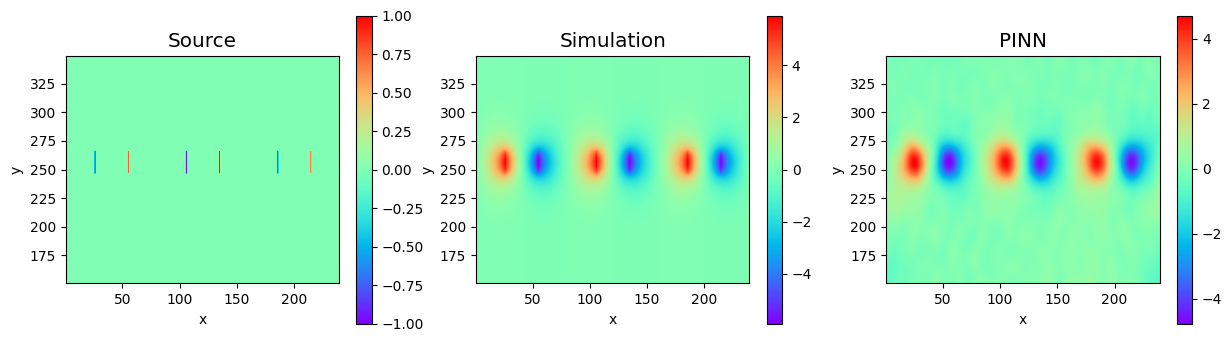

In [10]:
# solve problem
u, ssr, mse, mae, rl2 = compute_ls_ntask(param)
print('SSR = %.2e  MSE = %.2e  MAE = %.2e  RL2 = %.2e'%(ssr, mse, mae, rl2));

# plot solution
fig = plt.figure(figsize=(15, 4))
ax1 = fig.add_subplot(1,3,1)
s_plot = s.reshape(240, -1).T
mesh2 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.); 
plt.colorbar(mesh2); plt.xlabel('x'); plt.ylabel('y'); plt.title('Source', fontsize='x-large'); 
ax1 = fig.add_subplot(1,3,2)
s_plot = u_sim.reshape(240, -1).T
mesh2 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.); 
plt.colorbar(mesh2); plt.xlabel('x'); plt.ylabel('y'); plt.title('Simulation', fontsize='x-large'); 
ax1 = fig.add_subplot(1,3,3)
s_plot = u.reshape(240, -1).T
mesh2 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.); 
plt.colorbar(mesh2); plt.xlabel('x'); plt.ylabel('y'); plt.title('PINN', fontsize='x-large'); 

Time the run

In [11]:
%%timeit -n 10 -r 2
u, ssr, mse, rl2, mae = compute_ls_ntask(param)

641 ms ± 243 ms per loop (mean ± std. dev. of 2 runs, 10 loops each)
